# Measuring Hate Speech dataset: annotation-density and disagreement audit

This notebook helps you inspect whether the UC Berkeley D-Lab **Measuring Hate Speech (MHS)** dataset is usable for a project on human annotator variance and LLM persona simulation.

It answers questions such as:

- How many annotations are available per unique text/comment?
- How many unique annotators are available per text/comment?
- Which columns look like labels, demographics, target identities, text IDs, and annotator IDs?
- Which items have enough repeated annotations for item-level distribution matching?
- Which demographic groups have enough coverage per item?
- How much human disagreement is there per item?
- Which subset of the data is most useful for LLM evaluation?

The notebook is intentionally defensive: it tries to infer column names automatically, but you can override them in the configuration cell.

## 0. Setup
Run this once. Uncomment the `%pip install` line in a fresh environment.

In [1]:
# Uncomment if needed in a fresh environment:
# %pip install -q pandas numpy matplotlib datasets scipy scikit-learn krippendorff pyarrow openpyxl

import os
import re
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import datasets
warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 200)
pd.set_option("display.max_colwidth", 180)

## 1. Load the dataset

Two options are supported:

1. Load from Hugging Face: `ucberkeley-dlab/measuring-hate-speech`
2. Load a local file: `.csv`, `.tsv`, `.json`, `.jsonl`, `.parquet`, `.xlsx`

Set `DATA_PATH = None` to use Hugging Face.

In [2]:
# -------------------------
# CONFIG: edit these values
# -------------------------
DATA_PATH = None  # Example: "./measuring_hate_speech.csv". Use None to load from Hugging Face.
HF_DATASET_NAME = "ucberkeley-dlab/measuring-hate-speech"
HF_SPLIT = "train"

# Optional manual overrides. Leave as None to auto-detect.
TEXT_COL = None
ITEM_ID_COL = None
ANNOTATOR_ID_COL = None

# Manually set label columns if auto-detection misses something.
# Example: LABEL_COLS = ["hate_speech_score", "sentiment", "respect", "insult"]
LABEL_COLS = None

EXCLUDE_FROM_LABELS = set([
    "text", "comment", "sentence", "post", "tweet", "body", "content",
    "comment_id", "post_id", "text_id", "item_id", "annotator_id", "worker_id", "user_id",
])

In [3]:
def load_local_table(path):
    path = Path(path)
    suffix = path.suffix.lower()
    if suffix == ".csv":
        return pd.read_csv(path)
    if suffix in [".tsv", ".tab"]:
        return pd.read_csv(path, sep="	")
    if suffix in [".jsonl", ".ndjson"]:
        return pd.read_json(path, lines=True)
    if suffix == ".json":
        return pd.read_json(path)
    if suffix in [".parquet", ".pq"]:
        return pd.read_parquet(path)
    if suffix in [".xlsx", ".xls"]:
        return pd.read_excel(path)
    raise ValueError(f"Unsupported file extension: {suffix}")

if DATA_PATH is None:
    try:
        from datasets import load_dataset
        ds = load_dataset(HF_DATASET_NAME, split=HF_SPLIT)
        df = ds.to_pandas()
        print(f"Loaded Hugging Face dataset {HF_DATASET_NAME!r}, split={HF_SPLIT!r}")
    except Exception as e:
        raise RuntimeError(
            "Could not load from Hugging Face. Install `datasets`, check internet access, "
            "or set DATA_PATH to a local dataset file. Original error: " + repr(e)
        )
else:
    df = load_local_table(DATA_PATH)
    print(f"Loaded local file: {DATA_PATH}")

print("Shape:", df.shape)
display(df.head())

README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/20.1M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/135556 [00:00<?, ? examples/s]

Loaded Hugging Face dataset 'ucberkeley-dlab/measuring-hate-speech', split='train'
Shape: (135556, 143)


,comment_id,annotator_id,platform,sentiment,respect,insult,humiliate,status,dehumanize,violence,genocide,attack_defend,hatespeech,hate_speech_score,text,infitms,outfitms,annotator_severity,std_err,annotator_infitms,annotator_outfitms,hypothesis,target_race_asian,target_race_black,target_race_latinx,target_race_middle_eastern,target_race_native_american,target_race_pacific_islander,target_race_white,target_race_other,target_race,target_religion_atheist,target_religion_buddhist,target_religion_christian,target_religion_hindu,target_religion_jewish,target_religion_mormon,target_religion_muslim,target_religion_other,target_religion,target_origin_immigrant,target_origin_migrant_worker,target_origin_specific_country,target_origin_undocumented,target_origin_other,target_origin,target_gender_men,target_gender_non_binary,target_gender_transgender_men,target_gender_transgender_unspecified,target_gender_transgender_women,target_gender_women,target_gender_other,target_gender,target_sexuality_bisexual,target_sexuality_gay,target_sexuality_lesbian,target_sexuality_straight,target_sexuality_other,target_sexuality,target_age_children,target_age_teenagers,target_age_young_adults,target_age_middle_aged,target_age_seniors,target_age_other,target_age,target_disability_physical,target_disability_cognitive,target_disability_neurological,target_disability_visually_impaired,target_disability_hearing_impaired,target_disability_unspecific,target_disability_other,target_disability,target_politics_alt_right,target_politics_communist,target_politics_conservative,target_politics_democrat,target_politics_green_party,target_politics_leftist,target_politics_liberal,target_politics_libertarian,target_politics_republican,target_politics_socialist,target_politics_other,target_politics,annotator_gender,annotator_trans,annotator_educ,annotator_income,annotator_ideology,annotator_gender_men,annotator_gender_women,annotator_gender_non_binary,annotator_gender_prefer_not_to_say,annotator_gender_self_describe,annotator_transgender,annotator_cisgender,annotator_transgender_prefer_not_to_say,annotator_education_some_high_school,annotator_education_high_school_grad,annotator_education_some_college,annotator_education_college_grad_aa,annotator_education_college_grad_ba,annotator_education_professional_degree,annotator_education_masters,annotator_education_phd,annotator_income_<10k,annotator_income_10k-50k,annotator_income_50k-100k,annotator_income_100k-200k,annotator_income_>200k,annotator_ideology_extremeley_conservative,annotator_ideology_conservative,annotator_ideology_slightly_conservative,annotator_ideology_neutral,annotator_ideology_slightly_liberal,annotator_ideology_liberal,annotator_ideology_extremeley_liberal,annotator_ideology_no_opinion,annotator_race_asian,annotator_race_black,annotator_race_latinx,annotator_race_middle_eastern,annotator_race_native_american,annotator_race_pacific_islander,annotator_race_white,annotator_race_other,annotator_age,annotator_religion_atheist,annotator_religion_buddhist,annotator_religion_christian,annotator_religion_hindu,annotator_religion_jewish,annotator_religion_mormon,annotator_religion_muslim,annotator_religion_nothing,annotator_religion_other,annotator_sexuality_bisexual,annotator_sexuality_gay,annotator_sexuality_straight,annotator_sexuality_other
0,47777,10873,3,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,-3.90,"Yes indeed. She sort of reminds me of the elder lady that played the part in the movie ""Titanic"" who was telling her story!!! And I wouldn't have wanted to cover who I really a...",0.81,1.88,0.36,0.34,1.35,1.23,-1.130178,True,True,True,True,True,True,True,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,male,no,college_grad

## 2. Basic schema inspection
This prints column names, missingness, dtypes, and example values.

In [4]:
def normalize_name(c):
    return re.sub(r"[^a-z0-9]+", "_", str(c).lower()).strip("_")

col_norm = {c: normalize_name(c) for c in df.columns}

schema = pd.DataFrame({
    "column": df.columns,
    "normalized": [col_norm[c] for c in df.columns],
    "dtype": [str(df[c].dtype) for c in df.columns],
    "non_null": [df[c].notna().sum() for c in df.columns],
    "missing_pct": [df[c].isna().mean() * 100 for c in df.columns],
    "n_unique": [df[c].nunique(dropna=True) for c in df.columns],
    "example_values": [df[c].dropna().astype(str).head(3).tolist() for c in df.columns],
})

display(schema.sort_values(["dtype", "n_unique"]).reset_index(drop=True))

,column,normalized,dtype,non_null,missing_pct,n_unique,example_values
0,annotator_ideology_extremeley_liberal,annotator_ideology_extremeley_liberal,bool,135556,0.000000,1,"[False, False, False]"
1,target_race_asian,target_race_asian,bool,135556,0.000000,2,"[True, False, False]"
2,target_race_black,target_race_black,bool,135556,0.000000,2,"[True, False, False]"
3,target_race_latinx,target_race_latinx,bool,135556,0.000000,2,"[True, False, False]"
4,target_race_middle_eastern,target_race_middle_eastern,bool,135556,0.000000,2,"[True, False, False]"
...,...,...,...,...,...,...,...
138,annotator_gender,annotator_gender,str,135556,0.000000,5,"[male, female, male]"
139,annotator_income,annotator_income,str,135453,0.075983,5,"[<10k, <10k, 100k-200k]"
140,annotator_educ,annotator_educ,str,135539,0.012541,8,"[college_grad_ba, some_college, some_college]"
141,annotator_ideology,annotator_ideology,str,135529,0.019918,8,"[neutral, neutral, slightly_conservative]"


In [5]:
def find_first_col(patterns, columns):
    for pat in patterns:
        rx = re.compile(pat, re.I)
        matches = [c for c in columns if rx.search(str(c))]
        if matches:
            return matches[0]
    return None

if TEXT_COL is None:
    TEXT_COL = find_first_col([
        r"^text$", r"comment_text", r"^comment$", r"sentence", r"tweet", r"post", r"body", r"content"
    ], df.columns)

if ITEM_ID_COL is None:
    ITEM_ID_COL = find_first_col([
        r"comment.*id", r"text.*id", r"item.*id", r"post.*id", r"tweet.*id", r"^id$"
    ], df.columns)

if ANNOTATOR_ID_COL is None:
    ANNOTATOR_ID_COL = find_first_col([
        r"annotator.*id", r"worker.*id", r"rater.*id", r"coder.*id", r"turker.*id", r"labeler.*id"
    ], df.columns)

print("Detected TEXT_COL:", TEXT_COL)
print("Detected ITEM_ID_COL:", ITEM_ID_COL)
print("Detected ANNOTATOR_ID_COL:", ANNOTATOR_ID_COL)

if TEXT_COL is None:
    raise ValueError("Could not detect a text column. Set TEXT_COL manually in the config cell.")

Detected TEXT_COL: text
Detected ITEM_ID_COL: comment_id
Detected ANNOTATOR_ID_COL: annotator_id


## 3. Detect likely label, annotator-demographic, and target-identity columns
Inspect this output carefully. You can manually override `LABEL_COLS`, `DEMOGRAPHIC_COLS`, or `TARGET_COLS` after seeing the schema.

In [7]:
label_name_patterns = [
    r"hate", r"sentiment", r"respect", r"disrespect", r"insult", r"humiliat",
    r"inferior", r"superior", r"status", r"dehuman", r"violence", r"violent",
    r"genocide", r"attack", r"defen", r"benchmark", r"score"
]

demo_name_patterns = [
    r"annotator", r"rater", r"worker", r"coder", r"gender", r"race", r"ethnic",
    r"educ", r"income", r"age", r"ideolog", r"polit", r"relig", r"trans",
    r"sexual", r"orientation", r"disabil", r"citizen", r"national"
]

id_cols = {c for c in [TEXT_COL, ITEM_ID_COL, ANNOTATOR_ID_COL] if c is not None}

if LABEL_COLS is None:
    candidate_label_cols = []
    for c in df.columns:
        cn = normalize_name(c)
        if c in id_cols or cn in EXCLUDE_FROM_LABELS:
            continue
        if any(re.search(p, cn, re.I) for p in label_name_patterns):
            candidate_label_cols.append(c)
    LABEL_COLS = candidate_label_cols

DEMOGRAPHIC_COLS = []
for c in df.columns:
    cn = normalize_name(c)
    if c in id_cols or c in LABEL_COLS:
        continue
    if re.search(r"annotator|rater|worker|coder", cn, re.I) or any(re.search(p, cn, re.I) for p in demo_name_patterns):
        if not re.search(r"target", cn, re.I):
            DEMOGRAPHIC_COLS.append(c)

TARGET_COLS = []
for c in df.columns:
    cn = normalize_name(c)
    if c in id_cols or c in LABEL_COLS or c in DEMOGRAPHIC_COLS:
        continue
    if re.search(r"target|identity|subgroup", cn, re.I):
        TARGET_COLS.append(c)

print("Likely label columns:")
print(LABEL_COLS)
print("Likely annotator demographic columns:")
print(DEMOGRAPHIC_COLS)
print("Likely target identity columns:")
print(TARGET_COLS)

Likely label columns:
['sentiment', 'respect', 'insult', 'humiliate', 'status', 'dehumanize', 'violence', 'genocide', 'attack_defend', 'hatespeech', 'hate_speech_score']
Likely annotator demographic columns:
['annotator_severity', 'annotator_infitms', 'annotator_outfitms', 'annotator_gender', 'annotator_trans', 'annotator_educ', 'annotator_income', 'annotator_ideology', 'annotator_gender_men', 'annotator_gender_women', 'annotator_gender_non_binary', 'annotator_gender_prefer_not_to_say', 'annotator_gender_self_describe', 'annotator_transgender', 'annotator_cisgender', 'annotator_transgender_prefer_not_to_say', 'annotator_education_some_high_school', 'annotator_education_high_school_grad', 'annotator_education_some_college', 'annotator_education_college_grad_aa', 'annotator_education_college_grad_ba', 'annotator_education_professional_degree', 'annotator_education_masters', 'annotator_education_phd', 'annotator_income_<10k', 'annotator_income_10k-50k', 'annotator_income_50k-100k', 'annot

## 4. Create a stable item key and annotation key
If there is no comment ID, the notebook uses the exact text string as the item key.

In [8]:
work = df.copy()

if ITEM_ID_COL is not None and ITEM_ID_COL in work.columns:
    work["_item_key"] = work[ITEM_ID_COL].astype(str)
    item_key_source = ITEM_ID_COL
else:
    work["_item_key"] = work[TEXT_COL].astype(str)
    item_key_source = TEXT_COL

if ANNOTATOR_ID_COL is not None and ANNOTATOR_ID_COL in work.columns:
    work["_annotator_key"] = work[ANNOTATOR_ID_COL].astype(str)
else:
    work["_annotator_key"] = np.arange(len(work)).astype(str)

print("Item key source:", item_key_source)
print("Annotator key source:", ANNOTATOR_ID_COL if ANNOTATOR_ID_COL else "row index fallback")
print("Unique items:", work["_item_key"].nunique())
print("Unique annotators:", work["_annotator_key"].nunique())
print("Total annotation rows:", len(work))

Item key source: comment_id
Annotator key source: annotator_id
Unique items: 39565
Unique annotators: 7912
Total annotation rows: 135556


## 5. Main audit: annotations per unique sentence/comment

In [9]:
ann_per_item = (
    work.groupby("_item_key")
    .agg(
        n_rows=("_item_key", "size"),
        n_unique_annotators=("_annotator_key", "nunique"),
        text=(TEXT_COL, "first")
    )
    .reset_index()
    .sort_values("n_unique_annotators", ascending=False)
)

summary_stats = ann_per_item[["n_rows", "n_unique_annotators"]].describe(percentiles=[.1, .25, .5, .75, .9, .95, .99]).T
print("Annotation density summary:")
display(summary_stats)

print("Top 20 most annotated items:")
display(ann_per_item.head(20))

Annotation density summary:


,count,mean,std,min,10%,25%,50%,75%,90%,95%,99%,max
n_rows,39565.0,3.426159,26.958077,1.0,1.0,1.0,2.0,3.0,4.0,4.0,4.0,815.0
n_unique_annotators,39565.0,3.426159,26.958077,1.0,1.0,1.0,2.0,3.0,4.0,4.0,4.0,815.0


Top 20 most annotated items:


,_item_key,n_rows,n_unique_annotators,text
8685,20011,815,815,"JEW Get the fuck out of here you jewish son of a bitch, I'll rape your fucking family if you don't leave you semite bastard. I will shoot you if you return, because you're a di..."
8675,20002,801,801,"yeah, heres a clue for the nigger author of this article. Chinks hate niggers, Kikes hate niggers, Spicks hate niggers and Towelheads hate niggers. EVen niggers hate niggers. B..."
8674,20001,799,799,@Legionary1488 @JomavaesJos now we have a Ebloa case in Texas. If we kill all the niggers we might be safe.
8680,20007,796,796,Every slant in #LosAngeles should be deported. Those scum have no right to be here. Chinatown should be bulldozed.
8696,20022,793,793,Why do so many filthy wetback half-breed spic savages live in #LosAngeles? None of them have any right at all to be here.
8688,20014,793,793,"@Cam_Coles You don't know what I know. Name somebody colder, you monkey faced immigrant"
8708,20034,791,791,gay people should die
8722,20047,790,790,i hate jews so much i wish the holocaust actually happened
8744,20068,786,786,trump is the only jews true friend. I hope trump will be the next US president and help Israel to kill all Palestinian fucking muslim. we will kill all muslim in the world.
8682,20009,784,784,"GET RID OF THOSE FUCKING MUSLIMS! the nasty ones that won't assimilate, rape women, beat children, threaten democracy, plan terror attacks, assault innocent secular people and ..."


,n_unique_annotators,n_items,pct_items,cum_pct_items
0,1,10077,25.469481,25.469481
1,2,12136,30.673575,56.143056
2,3,11362,28.717301,84.860356
3,4,5709,14.429420,99.289776
4,5,208,0.525717,99.815493
...,...,...,...,...
65,793,2,0.005055,99.989890
66,796,1,0.002527,99.992418
67,799,1,0.002527,99.994945
68,801,1,0.002527,99.997473


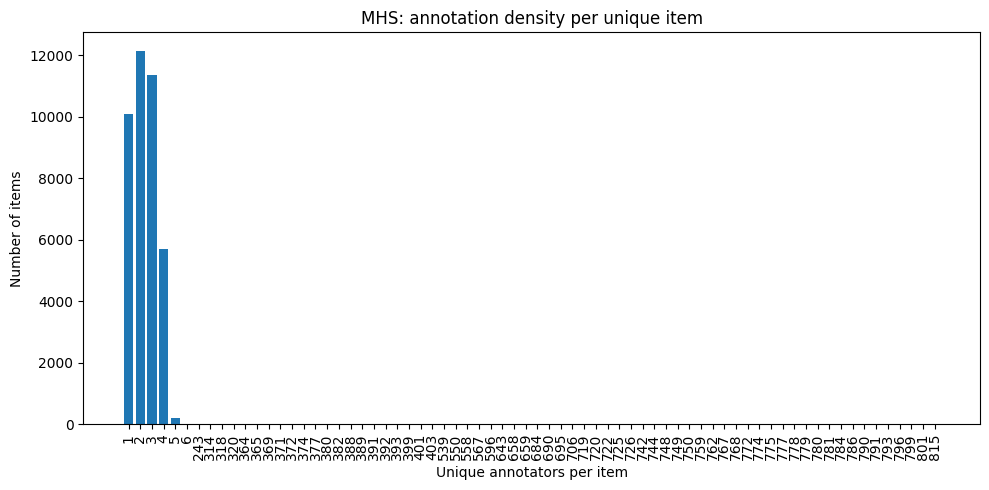

In [10]:
freq = ann_per_item["n_unique_annotators"].value_counts().sort_index().rename_axis("n_unique_annotators").reset_index(name="n_items")
freq["pct_items"] = 100 * freq["n_items"] / freq["n_items"].sum()
freq["cum_pct_items"] = freq["pct_items"].cumsum()
display(freq)

plt.figure(figsize=(10, 5))
plt.bar(freq["n_unique_annotators"].astype(str), freq["n_items"])
plt.xlabel("Unique annotators per item")
plt.ylabel("Number of items")
plt.title("MHS: annotation density per unique item")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [11]:
thresholds = [2, 3, 5, 8, 10, 15, 20]
coverage_rows = []
for t in thresholds:
    subset = ann_per_item[ann_per_item["n_unique_annotators"] >= t]
    n_rows = work[work["_item_key"].isin(subset["_item_key"])].shape[0]
    coverage_rows.append({
        "min_unique_annotators": t,
        "n_items": len(subset),
        "pct_items": 100 * len(subset) / len(ann_per_item),
        "n_annotation_rows": int(n_rows),
        "pct_annotation_rows": 100 * n_rows / len(work),
    })
coverage = pd.DataFrame(coverage_rows)
display(coverage)

,min_unique_annotators,n_items,pct_items,n_annotation_rows,pct_annotation_rows
0,2,29488,74.530519,125479,92.566172
1,3,17352,43.856944,101207,74.660657
2,5,281,0.710224,44285,32.669155
3,8,70,0.176924,43227,31.888666
4,10,70,0.176924,43227,31.888666
5,15,70,0.176924,43227,31.888666
6,20,70,0.176924,43227,31.888666


## 6. Annotator workload: items per annotator

,count,mean,std,min,10%,25%,50%,75%,90%,95%,99%,max
n_rows,7912.0,17.132963,3.825483,6.0,12.0,15.0,17.0,20.0,22.0,23.0,25.0,26.0
n_unique_items,7912.0,17.132963,3.825483,6.0,12.0,15.0,17.0,20.0,22.0,23.0,25.0,26.0


,_annotator_key,n_rows,n_unique_items
4794,6098,26,26
4759,6050,26,26
4342,5525,26,26
6539,8276,26,26
7279,9202,26,26
4973,6321,26,26
2575,3175,26,26
6769,8565,26,26
7572,9563,26,26
207,10262,26,26


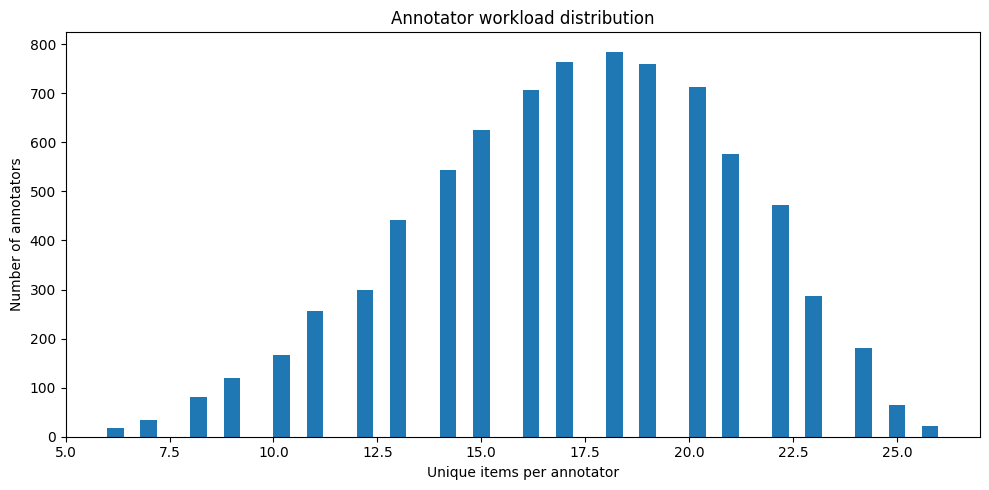

In [12]:
ann_per_annotator = (
    work.groupby("_annotator_key")
    .agg(n_rows=("_annotator_key", "size"), n_unique_items=("_item_key", "nunique"))
    .reset_index()
    .sort_values("n_unique_items", ascending=False)
)

display(ann_per_annotator[["n_rows", "n_unique_items"]].describe(percentiles=[.1, .25, .5, .75, .9, .95, .99]).T)
display(ann_per_annotator.head(20))

plt.figure(figsize=(10, 5))
plt.hist(ann_per_annotator["n_unique_items"], bins=50)
plt.xlabel("Unique items per annotator")
plt.ylabel("Number of annotators")
plt.title("Annotator workload distribution")
plt.tight_layout()
plt.show()

## 7. Label distributions
For continuous columns such as `hate_speech_score`, this produces histograms. For categorical/ordinal labels, it produces frequency tables.

LABEL COLUMN: sentiment
dtype: float64 | non-null: 135556 | unique: 5


,count,mean,std,min,1%,5%,10%,25%,50%,75%,90%,95%,99%,max
sentiment,135556.0,2.954307,1.231552,0.0,0.0,0.0,1.0,2.0,3.0,4.0,4.0,4.0,4.0,4.0


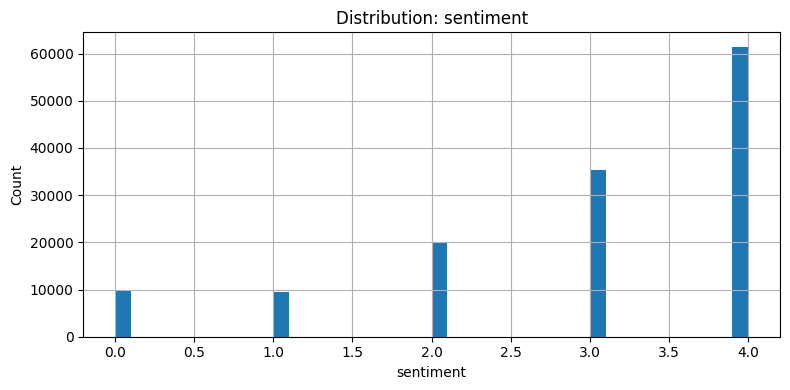

LABEL COLUMN: respect
dtype: float64 | non-null: 135556 | unique: 5


,count,mean,std,min,1%,5%,10%,25%,50%,75%,90%,95%,99%,max
respect,135556.0,2.828875,1.309548,0.0,0.0,0.0,1.0,2.0,3.0,4.0,4.0,4.0,4.0,4.0


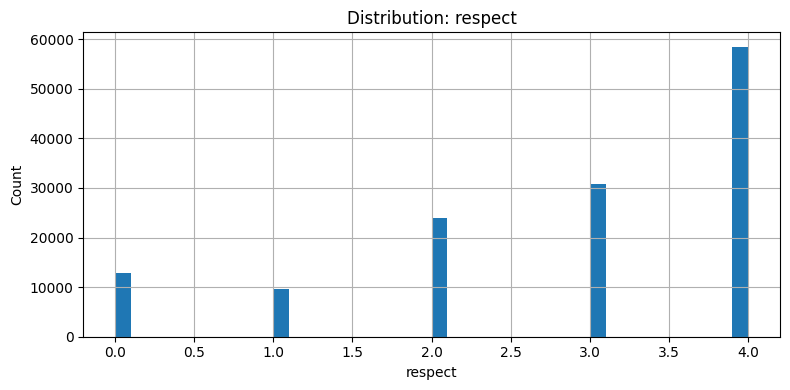

LABEL COLUMN: insult
dtype: float64 | non-null: 135556 | unique: 5


,count,mean,std,min,1%,5%,10%,25%,50%,75%,90%,95%,99%,max
insult,135556.0,2.56331,1.38983,0.0,0.0,0.0,0.0,2.0,3.0,4.0,4.0,4.0,4.0,4.0


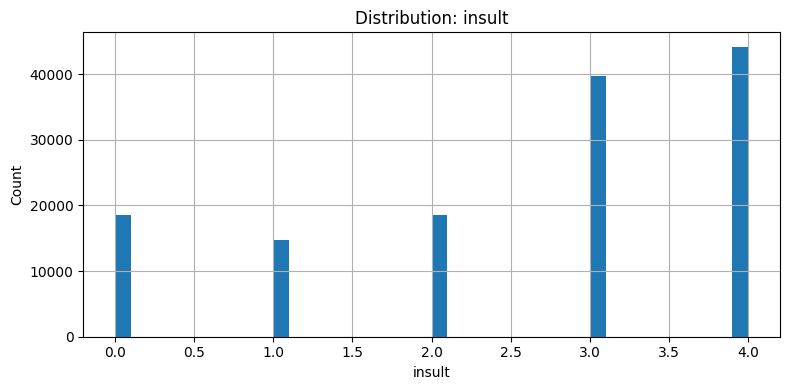

LABEL COLUMN: humiliate
dtype: float64 | non-null: 135556 | unique: 5


,count,mean,std,min,1%,5%,10%,25%,50%,75%,90%,95%,99%,max
humiliate,135556.0,2.278638,1.370876,0.0,0.0,0.0,0.0,1.0,3.0,3.0,4.0,4.0,4.0,4.0


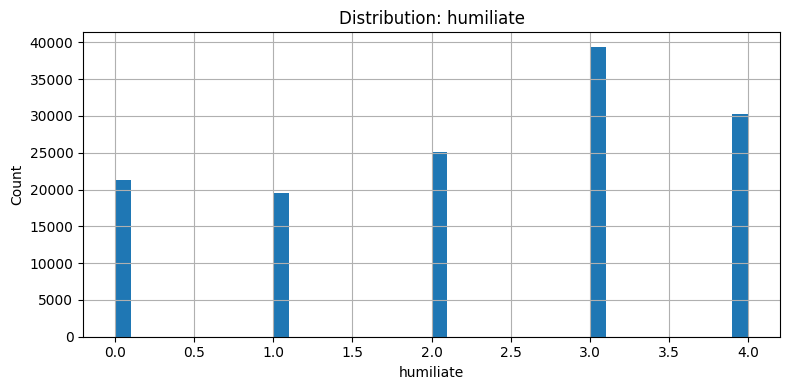

LABEL COLUMN: status
dtype: float64 | non-null: 135556 | unique: 5


,count,mean,std,min,1%,5%,10%,25%,50%,75%,90%,95%,99%,max
status,135556.0,2.698575,0.8985,0.0,1.0,2.0,2.0,2.0,3.0,3.0,4.0,4.0,4.0,4.0


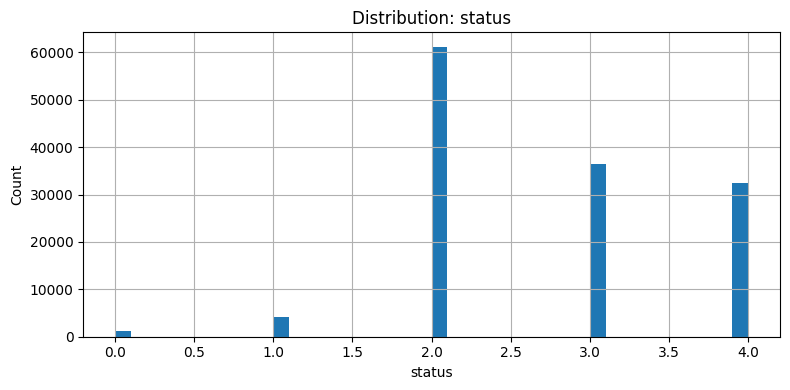

LABEL COLUMN: dehumanize
dtype: float64 | non-null: 135556 | unique: 5


,count,mean,std,min,1%,5%,10%,25%,50%,75%,90%,95%,99%,max
dehumanize,135556.0,1.846211,1.402372,0.0,0.0,0.0,0.0,1.0,2.0,3.0,4.0,4.0,4.0,4.0


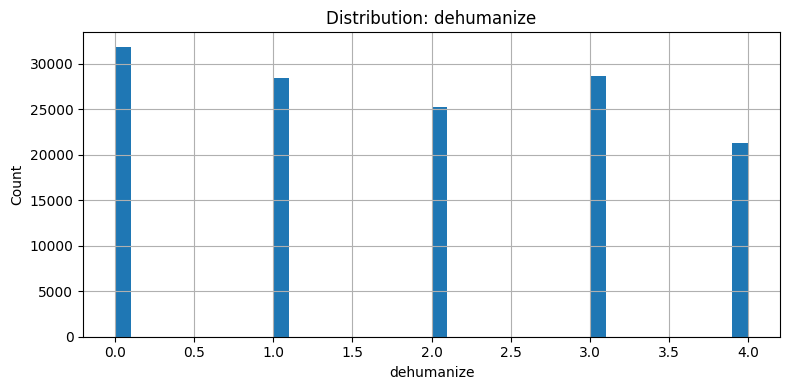

LABEL COLUMN: violence
dtype: float64 | non-null: 135556 | unique: 5


,count,mean,std,min,1%,5%,10%,25%,50%,75%,90%,95%,99%,max
violence,135556.0,1.052045,1.345706,0.0,0.0,0.0,0.0,0.0,0.0,2.0,3.0,4.0,4.0,4.0


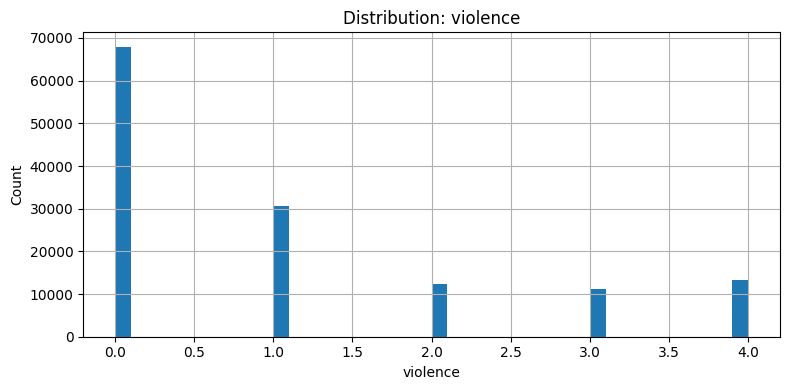

LABEL COLUMN: genocide
dtype: float64 | non-null: 135556 | unique: 5


,count,mean,std,min,1%,5%,10%,25%,50%,75%,90%,95%,99%,max
genocide,135556.0,0.678413,1.179598,0.0,0.0,0.0,0.0,0.0,0.0,1.0,3.0,4.0,4.0,4.0


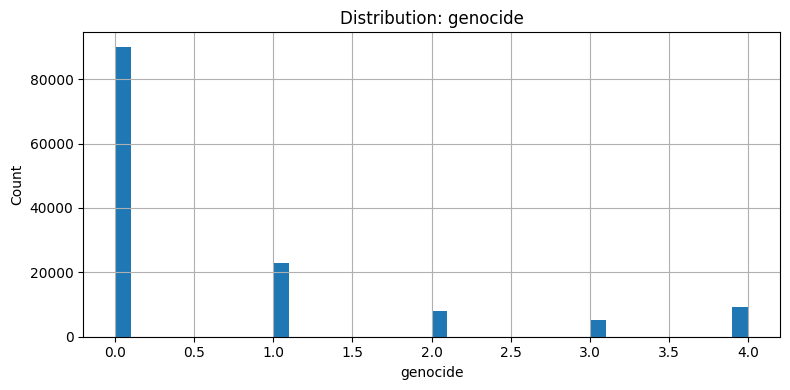

LABEL COLUMN: attack_defend
dtype: float64 | non-null: 135556 | unique: 5


,count,mean,std,min,1%,5%,10%,25%,50%,75%,90%,95%,99%,max
attack_defend,135556.0,2.625992,1.11496,0.0,0.0,0.0,1.0,2.0,3.0,3.0,4.0,4.0,4.0,4.0


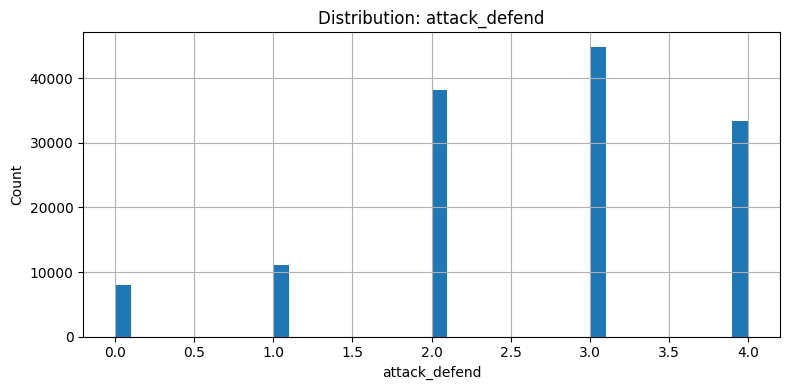

LABEL COLUMN: hatespeech
dtype: float64 | non-null: 135556 | unique: 3


,count,mean,std,min,1%,5%,10%,25%,50%,75%,90%,95%,99%,max
hatespeech,135556.0,0.744733,0.93226,0.0,0.0,0.0,0.0,0.0,0.0,2.0,2.0,2.0,2.0,2.0


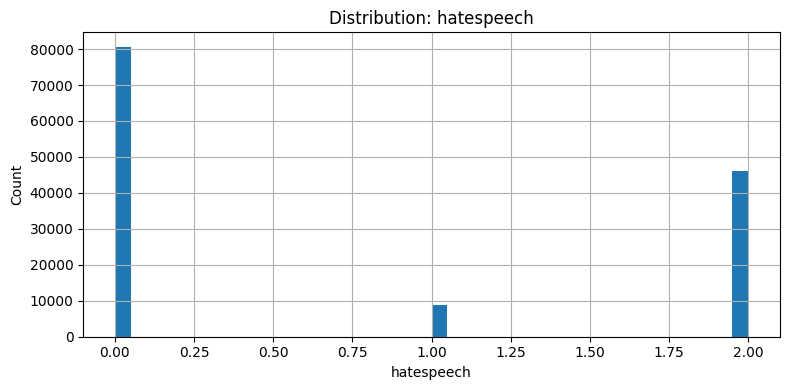

LABEL COLUMN: hate_speech_score
dtype: float64 | non-null: 135556 | unique: 1255


,count,mean,std,min,1%,5%,10%,25%,50%,75%,90%,95%,99%,max
hate_speech_score,135556.0,-0.567428,2.380003,-8.34,-5.94,-4.83,-4.04,-2.33,-0.34,1.41,2.36,2.97,3.62,6.3


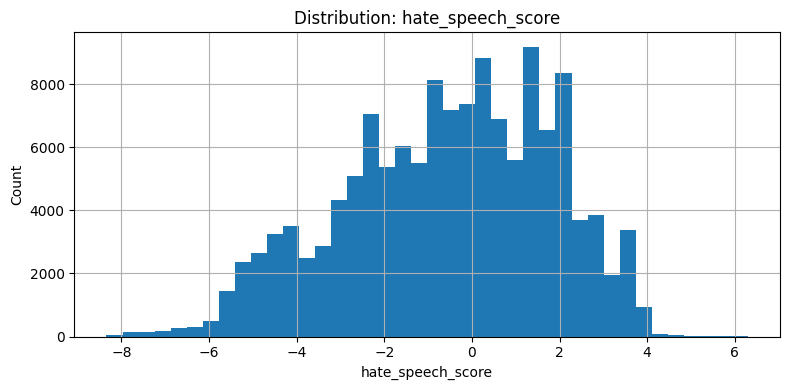

In [13]:
def is_numeric_like(s):
    return pd.api.types.is_numeric_dtype(s)

for col in LABEL_COLS:
    print("=" * 100)
    print("LABEL COLUMN:", col)
    s = work[col]
    print("dtype:", s.dtype, "| non-null:", s.notna().sum(), "| unique:", s.nunique(dropna=True))
    if is_numeric_like(s):
        display(s.describe(percentiles=[.01, .05, .1, .25, .5, .75, .9, .95, .99]).to_frame().T)
        plt.figure(figsize=(8, 4))
        s.dropna().hist(bins=40)
        plt.title(f"Distribution: {col}")
        plt.xlabel(col)
        plt.ylabel("Count")
        plt.tight_layout()
        plt.show()
    else:
        vc = s.fillna("<NA>").astype(str).value_counts(dropna=False).reset_index()
        vc.columns = [col, "count"]
        vc["pct"] = 100 * vc["count"] / vc["count"].sum()
        display(vc.head(30))

## 8. Item-level disagreement / entropy
For categorical or ordinal labels, entropy detects disagreement. For continuous scores, standard deviation is computed per item.

In [14]:
def entropy_from_counts(values):
    values = pd.Series(values).dropna()
    if len(values) == 0:
        return np.nan
    p = values.value_counts(normalize=True)
    return float(-(p * np.log2(p)).sum())

def normalized_entropy(values):
    values = pd.Series(values).dropna()
    k = values.nunique()
    if len(values) == 0 or k <= 1:
        return 0.0
    return float(entropy_from_counts(values) / np.log2(k))

item_disagreement = ann_per_item[["_item_key", "n_unique_annotators", "text"]].copy()

for col in LABEL_COLS:
    if work[col].nunique(dropna=True) <= 50 and not pd.api.types.is_float_dtype(work[col]):
        tmp = work.groupby("_item_key")[col].agg(
            **{f"{col}__entropy": entropy_from_counts,
               f"{col}__norm_entropy": normalized_entropy,
               f"{col}__n_unique_labels": lambda x: x.nunique(dropna=True)}
        ).reset_index()
    else:
        tmp = work.groupby("_item_key")[col].agg(
            **{f"{col}__mean": "mean",
               f"{col}__std": "std",
               f"{col}__min": "min",
               f"{col}__max": "max"}
        ).reset_index()
    item_disagreement = item_disagreement.merge(tmp, on="_item_key", how="left")

entropy_cols = [c for c in item_disagreement.columns if c.endswith("__norm_entropy")]
std_cols = [c for c in item_disagreement.columns if c.endswith("__std")]

print("Available entropy columns:", entropy_cols)
print("Available std columns:", std_cols)

sort_col = entropy_cols[0] if entropy_cols else (std_cols[0] if std_cols else "n_unique_annotators")
interesting = item_disagreement[item_disagreement["n_unique_annotators"] >= 5].sort_values(sort_col, ascending=False)
display(interesting.head(30))

Available entropy columns: []
Available std columns: ['sentiment__std', 'respect__std', 'insult__std', 'humiliate__std', 'status__std', 'dehumanize__std', 'violence__std', 'genocide__std', 'attack_defend__std', 'hatespeech__std', 'hate_speech_score__std']


,_item_key,n_unique_annotators,text,sentiment__mean,sentiment__std,sentiment__min,sentiment__max,respect__mean,respect__std,respect__min,respect__max,insult__mean,insult__std,insult__min,insult__max,humiliate__mean,humiliate__std,humiliate__min,humiliate__max,status__mean,status__std,status__min,status__max,dehumanize__mean,dehumanize__std,dehumanize__min,dehumanize__max,violence__mean,violence__std,violence__min,violence__max,genocide__mean,genocide__std,genocide__min,genocide__max,attack_defend__mean,attack_defend__std,attack_defend__min,attack_defend__max,hatespeech__mean,hatespeech__std,hatespeech__min,hatespeech__max,hate_speech_score__mean,hate_speech_score__std,hate_speech_score__min,hate_speech_score__max
185,13831,5,"For what they did to you, or for your primitive people's inability to keep your land? Get conquered you fucking savages. Shoulda wiped you all the fuck out instead of herding y...",3.200000,1.788854,0.0,4.0,4.000000,0.000000,4.0,4.0,3.800000,0.447214,3.0,4.0,3.800000,0.447214,3.0,4.0,4.000000,0.000000,4.0,4.0,3.200000,1.788854,0.0,4.0,3.200000,0.447214,3.0,4.0,2.800000,0.836660,2.0,4.0,3.800000,0.447214,3.0,4.0,1.600000,0.894427,0.0,2.0,2.94,0.0,2.94,2.94
227,47136,5,You EVIL LAND STEALING PALEFACE SAVAGES GO BACK TO YOUR CAVES IN EUROPE FIRST,3.000000,1.732051,0.0,4.0,3.200000,1.303840,1.0,4.0,3.000000,1.224745,1.0,4.0,2.600000,1.516575,0.0,4.0,2.800000,1.095445,1.0,4.0,2.400000,1.516575,0.0,4.0,0.600000,0.547723,0.0,1.0,0.200000,0.447214,0.0,1.0,2.600000,1.140175,1.0,4.0,0.800000,1.095445,0.0,2.0,0.17,0.0,0.17,0.17
166,14257,5,"Rome wasn't built in a day. And while god may be dead, Christianity is not yet.",1.600000,1.516575,0.0,3.0,1.600000,1.516575,0.0,3.0,1.200000,1.095445,0.0,2.0,1.400000,1.341641,0.0,3.0,2.200000,0.447214,2.0,3.0,1.000000,1.000000,0.0,2.0,1.400000,1.341641,0.0,3.0,1.200000,1.095445,0.0,2.0,1.800000,1.095445,0.0,3.0,0.000000,0.000000,0.0,0.0,-2.57,0.0,-2.57,-2.57
230,18553,5,"I know you're joking but that kinda hurts me, maybe I'm just being sensitive but Muslims aren't fucking animals, they're just people that are trying pass the day, like everyone...",2.200000,1.303840,1.0,4.0,1.600000,1.341641,0.0,3.0,1.000000,0.707107,0.0,2.0,1.400000,1.140175,0.0,3.0,2.200000,0.447214,2.0,3.0,1.000000,0.707107,0.0,2.0,0.600000,0.547723,0.0,1.0,0.600000,0.547723,0.0,1.0,0.800000,0.447214,0.0,1.0,0.200000,0.447214,0.0,1.0,-3.04,0.0,-3.04,-3.04
228,5747,5,Omg another transgirl aaaaah your so beautiful I'm also trans looking for trans friends,0.800000,1.303840,0.0,3.0,0.600000,1.341641,0.0,3.0,0.800000,1.303840,0.0,3.0,0.800000,1.303840,0.0,3.0,2.000000,0.000000,2.0,2.0,0.400000,0.547723,0.0,1.0,0.200000,0.447214,0.0,1.0,0.200000,0.447214,0.0,1.0,1.800000,0.447214,1.0,2.0,0.000000,0.000000,0.0,0.0,-3.82,0.0,-3.82,-3.82
131,6964,5,"It's pride month, being gay is a legal requirement.",2.200000,1.303840,0.0,3.0,2.200000,1.303840,0.0,3.0,1.800000,1.095445,0.0,3.0,1.600000,1.140175,0.0,3.0,2.200000,0.447214,2.0,3.0,0.800000,1.303840,0.0,3.0,0.200000,0.447214,0.0,1.0,0.200000,0.447214,0.0,1.0,2.400000,1.516575,0.0,4.0,0.000000,0.000000,0.0,0.0,-2.19,0.0,-2.19,-2.19
42,20048,643,>Some incels give a lot but get nothing back And so should be rewarded with pussy? Are you aware that said pussy is attached to a fully realized human being with the exact sa...,2.197512,1.281255,0.0,4.0,1.685848,1.263273,0.0,4.0,1.534992,1.224085,0.0,4.0,1.545879,1.224997,0.0,4.0,2.231726,0.653856,0.0,4.0,1.189736,1.123837,0.0,4.0,0.413686,0.685815,0.0,4.0,0.185070,0.461908,0.0,3.0,1.508554,1.329455,0.0,4.0,0.258165,0.627938,0.0,2.0,-2.36,0.0,-2.36,-2.36
86,13749,5,As a trans person myself it makes me very happy to see people like you stand up for us! I hope your family can set their hatred aside.,1.000000,1.224745,0.0,3.0,0.800000,0.836660,0.0,2.0,0.800000,0.836660,0.0,2.0,0.800000,0.836660,0.0,2.0,2.000000,0.000000,2.0,2.0,0.800000,0.836660,0.0,2.0,0.400000,0.894427,0.0,2.0,0.400000,0.894427,0.0,2.0,0.800000,0.836660,0.0,2.0,0.

## 9. Label distributions per item
These per-item label distributions are what you would later compare to LLM-generated distributions with JSD or related metrics.

In [15]:
SELECTED_LABEL = None  # Set manually after inspecting LABEL_COLS, or leave as None.

if SELECTED_LABEL is None:
    categorical_candidates = [c for c in LABEL_COLS if work[c].nunique(dropna=True) <= 20]
    SELECTED_LABEL = categorical_candidates[0] if categorical_candidates else (LABEL_COLS[0] if LABEL_COLS else None)

print("SELECTED_LABEL:", SELECTED_LABEL)

if SELECTED_LABEL is not None:
    item_label_counts = (
        work.dropna(subset=[SELECTED_LABEL])
        .groupby(["_item_key", SELECTED_LABEL])
        .size()
        .rename("count")
        .reset_index()
    )
    item_label_counts["prob"] = item_label_counts["count"] / item_label_counts.groupby("_item_key")["count"].transform("sum")
    display(item_label_counts.head(30))

    item_label_wide = item_label_counts.pivot_table(index="_item_key", columns=SELECTED_LABEL, values="prob", fill_value=0).reset_index()
    item_label_wide = item_label_wide.merge(ann_per_item[["_item_key", "n_unique_annotators", "text"]], on="_item_key", how="left")
    display(item_label_wide.sort_values("n_unique_annotators", ascending=False).head(20))
else:
    print("No label columns detected. Set LABEL_COLS manually in the config cell.")

SELECTED_LABEL: sentiment


,_item_key,sentiment,count,prob
0,1,3.0,1,0.250000
1,1,4.0,3,0.750000
2,10,3.0,2,0.666667
3,10,4.0,1,0.333333
4,100,2.0,1,1.000000
5,1000,2.0,2,1.000000
6,10001,4.0,2,1.000000
7,10003,4.0,1,1.000000
8,10005,4.0,4,1.000000
9,10006,0.0,1,0.333333


,_item_key,0.0,1.0,2.0,3.0,4.0,n_unique_annotators,text
8685,20011,0.000000,0.001227,0.000000,0.007362,0.991411,815,"JEW Get the fuck out of here you jewish son of a bitch, I'll rape your fucking family if you don't leave you semite bastard. I will shoot you if you return, because you're a di..."
8675,20002,0.000000,0.000000,0.001248,0.003745,0.995006,801,"yeah, heres a clue for the nigger author of this article. Chinks hate niggers, Kikes hate niggers, Spicks hate niggers and Towelheads hate niggers. EVen niggers hate niggers. B..."
8674,20001,0.000000,0.001252,0.003755,0.033792,0.961202,799,@Legionary1488 @JomavaesJos now we have a Ebloa case in Texas. If we kill all the niggers we might be safe.
8680,20007,0.000000,0.000000,0.002513,0.028894,0.968593,796,Every slant in #LosAngeles should be deported. Those scum have no right to be here. Chinatown should be bulldozed.
8696,20022,0.000000,0.000000,0.003783,0.013871,0.982346,793,Why do so many filthy wetback half-breed spic savages live in #LosAngeles? None of them have any right at all to be here.
8688,20014,0.002522,0.001261,0.002522,0.166456,0.827238,793,"@Cam_Coles You don't know what I know. Name somebody colder, you monkey faced immigrant"
8708,20034,0.000000,0.001264,0.001264,0.024020,0.973451,791,gay people should die
8722,20047,0.003797,0.000000,0.000000,0.017722,0.978481,790,i hate jews so much i wish the holocaust actually happened
8744,20068,0.002545,0.002545,0.005089,0.053435,0.936387,786,trump is the only jews true friend. I hope trump will be the next US president and help Israel to kill all Palestinian fucking muslim. we will kill all muslim in the world.
8682,20009,0.000000,0.001276,0.003827,0.012755,0.982143,784,"GET RID OF THOSE FUCKING MUSLIMS! the nasty ones that won't assimilate, rape women, beat children, threaten democracy, plan terror attacks, assault innocent secular people and ..."


## 10. Demographic coverage
This checks whether there are enough annotations from demographic subgroups to support persona experiments.

In [16]:
print("Detected demographic columns:")
print(DEMOGRAPHIC_COLS)

for col in DEMOGRAPHIC_COLS:
    print("=" * 100)
    print("DEMOGRAPHIC COLUMN:", col)
    vc = work[col].fillna("<NA>").astype(str).value_counts().reset_index()
    vc.columns = [col, "n_annotations"]
    vc["pct_annotations"] = 100 * vc["n_annotations"] / vc["n_annotations"].sum()
    display(vc.head(30))

Detected demographic columns:
['annotator_severity', 'annotator_infitms', 'annotator_outfitms', 'annotator_gender', 'annotator_trans', 'annotator_educ', 'annotator_income', 'annotator_ideology', 'annotator_gender_men', 'annotator_gender_women', 'annotator_gender_non_binary', 'annotator_gender_prefer_not_to_say', 'annotator_gender_self_describe', 'annotator_transgender', 'annotator_cisgender', 'annotator_transgender_prefer_not_to_say', 'annotator_education_some_high_school', 'annotator_education_high_school_grad', 'annotator_education_some_college', 'annotator_education_college_grad_aa', 'annotator_education_college_grad_ba', 'annotator_education_professional_degree', 'annotator_education_masters', 'annotator_education_phd', 'annotator_income_<10k', 'annotator_income_10k-50k', 'annotator_income_50k-100k', 'annotator_income_100k-200k', 'annotator_income_>200k', 'annotator_ideology_extremeley_conservative', 'annotator_ideology_conservative', 'annotator_ideology_slightly_conservative', 'an

,annotator_severity,n_annotations,pct_annotations
0,-0.21,1294,0.954587
1,-0.23,1210,0.892620
2,0.11,1209,0.891882
3,0.05,1181,0.871227
4,-0.07,1163,0.857948
5,0.1,1137,0.838768
6,-0.08,1136,0.838030
7,0.03,1117,0.824014
8,0.09,1115,0.822538
9,0.01,1112,0.820325


DEMOGRAPHIC COLUMN: annotator_infitms


,annotator_infitms,n_annotations,pct_annotations
0,0.87,2453,1.809584
1,0.84,2314,1.707044
2,0.88,2302,1.698191
3,0.93,2258,1.665732
4,0.97,2235,1.648765
5,0.82,2223,1.639913
6,0.79,2209,1.629585
7,0.92,2204,1.625896
8,0.89,2180,1.608191
9,0.99,2179,1.607454


DEMOGRAPHIC COLUMN: annotator_outfitms


...

,annotator_sexuality_gay,n_annotations,pct_annotations
0,False,130223,96.065833
1,True,5333,3.934167


DEMOGRAPHIC COLUMN: annotator_sexuality_straight


,annotator_sexuality_straight,n_annotations,pct_annotations
0,True,115539,85.233409
1,False,20017,14.766591


DEMOGRAPHIC COLUMN: annotator_sexuality_other


,annotator_sexuality_other,n_annotations,pct_annotations
0,False,133473,98.463366
1,True,2083,1.536634


SELECTED_DEMO: annotator_gender_men


,_item_key,False,True,n_demo_groups_present,max_group_count,min_nonzero_group_count,n_unique_annotators,text
8685,20011,468.0,347.0,2,468.0,347.0,815,"JEW Get the fuck out of here you jewish son of a bitch, I'll rape your fucking family if you don't leave you semite bastard. I will shoot you if you return, because you're a di..."
8675,20002,474.0,327.0,2,474.0,327.0,801,"yeah, heres a clue for the nigger author of this article. Chinks hate niggers, Kikes hate niggers, Spicks hate niggers and Towelheads hate niggers. EVen niggers hate niggers. B..."
8674,20001,460.0,339.0,2,460.0,339.0,799,@Legionary1488 @JomavaesJos now we have a Ebloa case in Texas. If we kill all the niggers we might be safe.
8680,20007,437.0,359.0,2,437.0,359.0,796,Every slant in #LosAngeles should be deported. Those scum have no right to be here. Chinatown should be bulldozed.
8688,20014,472.0,321.0,2,472.0,321.0,793,"@Cam_Coles You don't know what I know. Name somebody colder, you monkey faced immigrant"
8696,20022,448.0,345.0,2,448.0,345.0,793,Why do so many filthy wetback half-breed spic savages live in #LosAngeles? None of them have any right at all to be here.
8708,20034,437.0,354.0,2,437.0,354.0,791,gay people should die
8722,20047,430.0,360.0,2,430.0,360.0,790,i hate jews so much i wish the holocaust actually happened
8744,20068,475.0,311.0,2,475.0,311.0,786,trump is the only jews true friend. I hope trump will be the next US president and help Israel to kill all Palestinian fucking muslim. we will kill all muslim in the world.
8682,20009,465.0,319.0,2,465.0,319.0,784,"GET RID OF THOSE FUCKING MUSLIMS! the nasty ones that won't assimilate, rape women, beat children, threaten democracy, plan terror attacks, assault innocent secular people and ..."


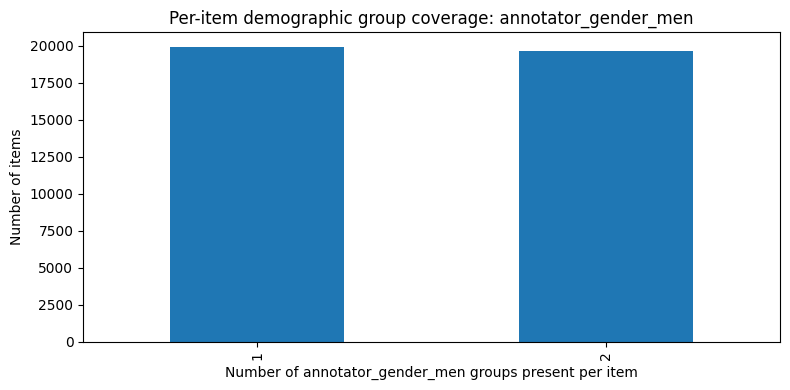

In [17]:
SELECTED_DEMO = None  # Example: "annotator_gender" or "annotator_ideology"

if SELECTED_DEMO is None and DEMOGRAPHIC_COLS:
    demo_rank = []
    for c in DEMOGRAPHIC_COLS:
        demo_rank.append((c, work[c].nunique(dropna=True), work[c].isna().mean()))
    demo_rank = pd.DataFrame(demo_rank, columns=["col", "n_unique", "missing_rate"])
    demo_rank = demo_rank[(demo_rank["n_unique"] >= 2) & (demo_rank["n_unique"] <= 20)].sort_values(["missing_rate", "n_unique"])
    if len(demo_rank):
        SELECTED_DEMO = demo_rank.iloc[0]["col"]

print("SELECTED_DEMO:", SELECTED_DEMO)

if SELECTED_DEMO is not None:
    per_item_demo_counts = (
        work.dropna(subset=[SELECTED_DEMO])
        .groupby(["_item_key", SELECTED_DEMO])["_annotator_key"]
        .nunique()
        .rename("n_unique_annotators")
        .reset_index()
    )
    demo_wide = per_item_demo_counts.pivot_table(index="_item_key", columns=SELECTED_DEMO, values="n_unique_annotators", fill_value=0)
    demo_wide["n_demo_groups_present"] = (demo_wide > 0).sum(axis=1)
    demo_wide["max_group_count"] = demo_wide.drop(columns=["n_demo_groups_present"]).max(axis=1)
    demo_wide["min_nonzero_group_count"] = demo_wide.drop(columns=["n_demo_groups_present", "max_group_count"]).replace(0, np.nan).min(axis=1)
    demo_wide = demo_wide.reset_index().merge(ann_per_item[["_item_key", "n_unique_annotators", "text"]], on="_item_key", how="left")
    display(demo_wide.sort_values(["n_demo_groups_present", "n_unique_annotators"], ascending=False).head(30))

    plt.figure(figsize=(8, 4))
    demo_wide["n_demo_groups_present"].value_counts().sort_index().plot(kind="bar")
    plt.xlabel(f"Number of {SELECTED_DEMO} groups present per item")
    plt.ylabel("Number of items")
    plt.title(f"Per-item demographic group coverage: {SELECTED_DEMO}")
    plt.tight_layout()
    plt.show()
else:
    print("No demographic column selected. Set SELECTED_DEMO manually.")

## 11. Intersectional coverage
This checks whether combinations such as gender x ideology or gender x race have enough observations.

In [18]:
INTERSECTIONAL_COLS = []  # Example: ["annotator_gender", "annotator_ideology"]

if not INTERSECTIONAL_COLS:
    manageable = []
    for c in DEMOGRAPHIC_COLS:
        n = work[c].nunique(dropna=True)
        miss = work[c].isna().mean()
        if 2 <= n <= 10 and miss < 0.5:
            manageable.append(c)
    INTERSECTIONAL_COLS = manageable[:2]

print("INTERSECTIONAL_COLS:", INTERSECTIONAL_COLS)

if len(INTERSECTIONAL_COLS) >= 2:
    tmp = work.dropna(subset=INTERSECTIONAL_COLS).copy()
    tmp["_intersectional_group"] = tmp[INTERSECTIONAL_COLS].astype(str).agg(" | ".join, axis=1)
    inter_counts = tmp["_intersectional_group"].value_counts().reset_index()
    inter_counts.columns = ["intersectional_group", "n_annotations"]
    inter_counts["pct_annotations"] = 100 * inter_counts["n_annotations"] / inter_counts["n_annotations"].sum()
    display(inter_counts.head(50))

    per_item_inter = tmp.groupby(["_item_key", "_intersectional_group"])["_annotator_key"].nunique().rename("n_unique_annotators").reset_index()
    inter_wide = per_item_inter.pivot_table(index="_item_key", columns="_intersectional_group", values="n_unique_annotators", fill_value=0)
    inter_wide["n_intersectional_groups_present"] = (inter_wide > 0).sum(axis=1)
    inter_wide = inter_wide.reset_index().merge(ann_per_item[["_item_key", "n_unique_annotators", "text"]], on="_item_key", how="left")
    display(inter_wide.sort_values(["n_intersectional_groups_present", "n_unique_annotators"], ascending=False).head(30))
else:
    print("Need at least two demographic columns for intersectional coverage.")

INTERSECTIONAL_COLS: ['annotator_gender', 'annotator_trans']


,intersectional_group,n_annotations,pct_annotations
0,female | no,75960,56.035882
1,male | no,57033,42.073387
2,non-binary | yes,526,0.388032
3,non-binary | no,351,0.258934
4,male | yes,325,0.239753
5,prefer_not_to_say | no,309,0.227950
6,female | yes,279,0.205819
7,male | prefer_not_to_say,224,0.165245
8,prefer_not_to_say | prefer_not_to_say,174,0.128360
9,female | prefer_not_to_say,131,0.096639


,_item_key,female | no,female | prefer_not_to_say,female | yes,male | no,male | prefer_not_to_say,male | yes,non-binary | no,non-binary | prefer_not_to_say,non-binary | yes,prefer_not_to_say | no,prefer_not_to_say | prefer_not_to_say,prefer_not_to_say | yes,self-describe | no,self-describe | prefer_not_to_say,self-describe | yes,n_intersectional_groups_present,n_unique_annotators,text
8675,20002,462.0,1.0,1.0,323.0,1.0,3.0,3.0,2.0,2.0,1.0,0.0,1.0,0.0,0.0,1.0,12,801,"yeah, heres a clue for the nigger author of this article. Chinks hate niggers, Kikes hate niggers, Spicks hate niggers and Towelheads hate niggers. EVen niggers hate niggers. B..."
8680,20007,421.0,1.0,4.0,354.0,3.0,2.0,3.0,1.0,2.0,0.0,2.0,0.0,2.0,1.0,0.0,12,796,Every slant in #LosAngeles should be deported. Those scum have no right to be here. Chinatown should be bulldozed.
8722,20047,418.0,0.0,2.0,353.0,2.0,5.0,2.0,1.0,3.0,0.0,1.0,0.0,1.0,1.0,1.0,12,790,i hate jews so much i wish the holocaust actually happened
8736,20060,422.0,1.0,2.0,330.0,4.0,2.0,3.0,2.0,5.0,2.0,0.0,1.0,1.0,0.0,0.0,12,775,I love that you enjoy being trans.
8692,20018,438.0,2.0,2.0,317.0,1.0,1.0,1.0,2.0,4.0,2.0,0.0,0.0,1.0,1.0,0.0,12,772,"RT @JihadistJoe: We Muslims have no military honour whatsoever, we are sub human savages that slaughter unarmed men, women & children http:…"
8694,20020,425.0,2.0,3.0,321.0,1.0,1.0,1.0,1.0,6.0,4.0,2.0,0.0,0.0,0.0,1.0,12,768,"They all need to be Kicked, taken out of our country. Obama brought them all in Illegally. Send the Trash back to there own country"
8691,20017,412.0,0.0,4.0,348.0,1.0,2.0,3.0,0.0,4.0,1.0,1.0,0.0,1.0,0.0,1.0,11,778,"My God look at these BARBARIC PPL. And these pigs all watching. They r a very, very sick culture. And Omar and Rashid want this crap here. This is America not the Middle East. ..."
8677,20004,415.0,1.0,2.0,313.0,3.0,2.0,3.0,1.0,3.0,4.0,1.0,0.0,0.0,0.0,0.0,11,748,ayo i even kill handicapped and crippled bitches/look at my scalp real close and you'll see triple sixes
8742,20066,417.0,0.0,1.0,292.0,2.0,0.0,0.0,1.0,2.0,1.0,2.0,0.0,2.0,1.0,1.0,11,722,NUGS lauds Ghanaian Muslims for their immense contribution to peace and progess - URL
8682,20009,450.0,3.0,1.0,316.0,2.0,1.0,3.0,0.0,6.0,1.0,1.0,0.0,0.0,0.0,0.0,10,784,"GET RID OF THOSE FUCKING MUSLIMS! the nasty ones that won't assimilate, rape women, beat children, threaten democracy, plan terror attacks, assault innocent secular people and ..."


## 12. Target identity coverage
This helps test whether annotator demographics interact with the target identity of the comment.

In [19]:
print("Detected target identity columns:")
print(TARGET_COLS)

for col in TARGET_COLS[:20]:
    print("=" * 100)
    print("TARGET COLUMN:", col)
    vc = work[col].fillna("<NA>").astype(str).value_counts().reset_index()
    vc.columns = [col, "n_annotations"]
    vc["pct_annotations"] = 100 * vc["n_annotations"] / vc["n_annotations"].sum()
    display(vc.head(30))

Detected target identity columns:
['target_race_asian', 'target_race_black', 'target_race_latinx', 'target_race_middle_eastern', 'target_race_native_american', 'target_race_pacific_islander', 'target_race_white', 'target_race_other', 'target_race', 'target_religion_atheist', 'target_religion_buddhist', 'target_religion_christian', 'target_religion_hindu', 'target_religion_jewish', 'target_religion_mormon', 'target_religion_muslim', 'target_religion_other', 'target_religion', 'target_origin_immigrant', 'target_origin_migrant_worker', 'target_origin_specific_country', 'target_origin_undocumented', 'target_origin_other', 'target_origin', 'target_gender_men', 'target_gender_non_binary', 'target_gender_transgender_men', 'target_gender_transgender_unspecified', 'target_gender_transgender_women', 'target_gender_women', 'target_gender_other', 'target_gender', 'target_sexuality_bisexual', 'target_sexuality_gay', 'target_sexuality_lesbian', 'target_sexuality_straight', 'target_sexuality_other', 

,target_race_asian,n_annotations,pct_annotations
0,False,128531,94.81764
1,True,7025,5.18236


TARGET COLUMN: target_race_black


,target_race_black,n_annotations,pct_annotations
0,False,112657,83.10735
1,True,22899,16.89265


TARGET COLUMN: target_race_latinx


...

,target_religion,n_annotations,pct_annotations
0,False,109374,80.685473
1,True,26182,19.314527


TARGET COLUMN: target_origin_immigrant


,target_origin_immigrant,n_annotations,pct_annotations
0,False,126031,92.973384
1,True,9525,7.026616


TARGET COLUMN: target_origin_migrant_worker


,target_origin_migrant_worker,n_annotations,pct_annotations
0,False,133033,98.138777
1,True,2523,1.861223


## 13. Candidate subset for LLM evaluation
Creates a subset of items with enough human annotations and exports it as CSV.

In [20]:
MIN_ANNOTATORS_PER_ITEM = 5
MAX_ITEMS_TO_EXPORT = 500  # set None to export all eligible items

eligible_items = ann_per_item[ann_per_item["n_unique_annotators"] >= MIN_ANNOTATORS_PER_ITEM].copy()
print(f"Eligible items with >= {MIN_ANNOTATORS_PER_ITEM} unique annotators:", len(eligible_items))

eligible_items = eligible_items.merge(
    item_disagreement.drop(columns=["text", "n_unique_annotators"], errors="ignore"),
    on="_item_key", how="left"
)

sort_cols = []
if entropy_cols:
    sort_cols.append(entropy_cols[0])
if std_cols:
    sort_cols.append(std_cols[0])
sort_cols.append("n_unique_annotators")

eligible_sorted = eligible_items.sort_values(sort_cols, ascending=False)
if MAX_ITEMS_TO_EXPORT is not None:
    eligible_sorted = eligible_sorted.head(MAX_ITEMS_TO_EXPORT)

display(eligible_sorted.head(30))

out_path = Path("mhs_candidate_items_for_llm_eval.csv")
eligible_sorted.to_csv(out_path, index=False)
print("Wrote:", out_path.resolve())

Eligible items with >= 5 unique annotators: 281


,_item_key,n_rows,n_unique_annotators,text,sentiment__mean,sentiment__std,sentiment__min,sentiment__max,respect__mean,respect__std,respect__min,respect__max,insult__mean,insult__std,insult__min,insult__max,humiliate__mean,humiliate__std,humiliate__min,humiliate__max,status__mean,status__std,status__min,status__max,dehumanize__mean,dehumanize__std,dehumanize__min,dehumanize__max,violence__mean,violence__std,violence__min,violence__max,genocide__mean,genocide__std,genocide__min,genocide__max,attack_defend__mean,attack_defend__std,attack_defend__min,attack_defend__max,hatespeech__mean,hatespeech__std,hatespeech__min,hatespeech__max,hate_speech_score__mean,hate_speech_score__std,hate_speech_score__min,hate_speech_score__max
185,13831,5,5,"For what they did to you, or for your primitive people's inability to keep your land? Get conquered you fucking savages. Shoulda wiped you all the fuck out instead of herding y...",3.200000,1.788854,0.0,4.0,4.000000,0.000000,4.0,4.0,3.800000,0.447214,3.0,4.0,3.800000,0.447214,3.0,4.0,4.000000,0.000000,4.0,4.0,3.200000,1.788854,0.0,4.0,3.200000,0.447214,3.0,4.0,2.800000,0.836660,2.0,4.0,3.800000,0.447214,3.0,4.0,1.600000,0.894427,0.0,2.0,2.94,0.0,2.94,2.94
227,47136,5,5,You EVIL LAND STEALING PALEFACE SAVAGES GO BACK TO YOUR CAVES IN EUROPE FIRST,3.000000,1.732051,0.0,4.0,3.200000,1.303840,1.0,4.0,3.000000,1.224745,1.0,4.0,2.600000,1.516575,0.0,4.0,2.800000,1.095445,1.0,4.0,2.400000,1.516575,0.0,4.0,0.600000,0.547723,0.0,1.0,0.200000,0.447214,0.0,1.0,2.600000,1.140175,1.0,4.0,0.800000,1.095445,0.0,2.0,0.17,0.0,0.17,0.17
166,14257,5,5,"Rome wasn't built in a day. And while god may be dead, Christianity is not yet.",1.600000,1.516575,0.0,3.0,1.600000,1.516575,0.0,3.0,1.200000,1.095445,0.0,2.0,1.400000,1.341641,0.0,3.0,2.200000,0.447214,2.0,3.0,1.000000,1.000000,0.0,2.0,1.400000,1.341641,0.0,3.0,1.200000,1.095445,0.0,2.0,1.800000,1.095445,0.0,3.0,0.000000,0.000000,0.0,0.0,-2.57,0.0,-2.57,-2.57
131,6964,5,5,"It's pride month, being gay is a legal requirement.",2.200000,1.303840,0.0,3.0,2.200000,1.303840,0.0,3.0,1.800000,1.095445,0.0,3.0,1.600000,1.140175,0.0,3.0,2.200000,0.447214,2.0,3.0,0.800000,1.303840,0.0,3.0,0.200000,0.447214,0.0,1.0,0.200000,0.447214,0.0,1.0,2.400000,1.516575,0.0,4.0,0.000000,0.000000,0.0,0.0,-2.19,0.0,-2.19,-2.19
228,5747,5,5,Omg another transgirl aaaaah your so beautiful I'm also trans looking for trans friends,0.800000,1.303840,0.0,3.0,0.600000,1.341641,0.0,3.0,0.800000,1.303840,0.0,3.0,0.800000,1.303840,0.0,3.0,2.000000,0.000000,2.0,2.0,0.400000,0.547723,0.0,1.0,0.200000,0.447214,0.0,1.0,0.200000,0.447214,0.0,1.0,1.800000,0.447214,1.0,2.0,0.000000,0.000000,0.0,0.0,-3.82,0.0,-3.82,-3.82
230,18553,5,5,"I know you're joking but that kinda hurts me, maybe I'm just being sensitive but Muslims aren't fucking animals, they're just people that are trying pass the day, like everyone...",2.200000,1.303840,1.0,4.0,1.600000,1.341641,0.0,3.0,1.000000,0.707107,0.0,2.0,1.400000,1.140175,0.0,3.0,2.200000,0.447214,2.0,3.0,1.000000,0.707107,0.0,2.0,0.600000,0.547723,0.0,1.0,0.600000,0.547723,0.0,1.0,0.800000,0.447214,0.0,1.0,0.200000,0.447214,0.0,1.0,-3.04,0.0,-3.04,-3.04
42,20048,643,643,>Some incels give a lot but get nothing back And so should be rewarded with pussy? Are you aware that said pussy is attached to a fully realized human being with the exact sa...,2.197512,1.281255,0.0,4.0,1.685848,1.263273,0.0,4.0,1.534992,1.224085,0.0,4.0,1.545879,1.224997,0.0,4.0,2.231726,0.653856,0.0,4.0,1.189736,1.123837,0.0,4.0,0.413686,0.685815,0.0,4.0,0.185070,0.461908,0.0,3.0,1.508554,1.329455,0.0,4.0,0.258165,0.627938,0.0,2.0,-2.36,0.0,-2.36,-2.36
86,13749,5,5,As a trans person myself it makes me very happy to see people like you stand up for us! I hope your family can set their hatred aside.,1.000000,1.224745,0.0,3.0,0.800000,0.836660,0.0,2.0,0.800000,0.836660,0.0,2.0,0.800000,0.836660,0.0,2.0,2.000000,0.000000,2.0,2.0,0.800000,0.836660,0.0,2.0,0.400000,0.894427,0.0,2.0,0.400000,0.894427,0.0,2.0,0.8

Wrote: /home/mmasiello/Desktop/Projects/nlp_proj/mhs_candidate_items_for_llm_eval.csv


## 14. Jensen-Shannon divergence helper for later LLM comparison
Once you have LLM outputs, save them with `_item_key`, `persona`, and `label`, then compare human and LLM distributions.

In [21]:
def js_divergence(p, q, base=2):
    p = np.asarray(p, dtype=float)
    q = np.asarray(q, dtype=float)
    if p.sum() == 0 or q.sum() == 0:
        return np.nan
    p = p / p.sum()
    q = q / q.sum()
    m = 0.5 * (p + q)
    def kl(a, b):
        mask = a > 0
        return np.sum(a[mask] * (np.log(a[mask] / b[mask]) / np.log(base)))
    return 0.5 * kl(p, m) + 0.5 * kl(q, m)

def distribution_table(data, item_col, label_col, group_col=None):
    keys = [item_col] + ([group_col] if group_col else []) + [label_col]
    counts = data.dropna(subset=[label_col]).groupby(keys).size().rename("count").reset_index()
    denom_keys = [item_col] + ([group_col] if group_col else [])
    counts["prob"] = counts["count"] / counts.groupby(denom_keys)["count"].transform("sum")
    return counts

if SELECTED_LABEL is not None:
    human_dist = distribution_table(work, "_item_key", SELECTED_LABEL)
    display(human_dist.head())

,_item_key,sentiment,count,prob
0,1,3.0,1,0.250000
1,1,4.0,3,0.750000
2,10,3.0,2,0.666667
3,10,4.0,1,0.333333
4,100,2.0,1,1.000000


## 15. Optional: Krippendorff's alpha
This is a quick global agreement estimate. For truly ordinal labels, define an explicit ordered mapping before computing alpha.

In [22]:
try:
    import krippendorff
    HAS_KRIPPENDORFF = True
except Exception:
    HAS_KRIPPENDORFF = False
    print("Package `krippendorff` is not installed. Run: %pip install krippendorff")

KRIPP_LABEL = SELECTED_LABEL
LEVEL_OF_MEASUREMENT = "ordinal"  # "nominal", "ordinal", "interval", or "ratio"

if HAS_KRIPPENDORFF and KRIPP_LABEL is not None:
    tmp = work[["_item_key", "_annotator_key", KRIPP_LABEL]].dropna().copy()
    if not pd.api.types.is_numeric_dtype(tmp[KRIPP_LABEL]):
        tmp["_label_num"], label_index = pd.factorize(tmp[KRIPP_LABEL], sort=True)
        print("Factorized label mapping:")
        display(pd.DataFrame({"code": range(len(label_index)), "label": label_index.astype(str)}))
    else:
        tmp["_label_num"] = tmp[KRIPP_LABEL]

    matrix = tmp.pivot_table(index="_annotator_key", columns="_item_key", values="_label_num", aggfunc="first")
    print("Reliability matrix shape annotators x items:", matrix.shape)
    alpha = krippendorff.alpha(reliability_data=matrix.to_numpy(), level_of_measurement=LEVEL_OF_MEASUREMENT)
    print(f"Krippendorff's alpha for {KRIPP_LABEL!r} ({LEVEL_OF_MEASUREMENT}):", alpha)
else:
    print("Skipping Krippendorff's alpha.")

Reliability matrix shape annotators x items: (7912, 39565)
Krippendorff's alpha for 'sentiment' (ordinal): 0.6878870693610484


## 16. Practical interpretation checklist

After running the notebook, inspect:

1. **Annotation-density frequency table**: are there enough items with >=5, >=8, or >=10 annotators?
2. **Demographic coverage**: do demographic groups repeat on the same items, or only in aggregate?
3. **Intersectional coverage**: are intersectional groups too sparse for reliable per-item comparison?
4. **Disagreement/entropy**: do you have genuinely controversial items?
5. **Candidate export**: use `mhs_candidate_items_for_llm_eval.csv` as a starting prompt set.

For your project, the strongest items usually have many unique annotators, high disagreement, demographic diversity among annotators, target-identity metadata, and non-trivial label distributions.